# 2 Ensamblados paralelos heterogéneos 

Para esta parte utilizaremos un famoso dataset sobre la calidad de vinos, que se puede descargar desde https://archive.ics.uci.edu/dataset/186/wine+qualitym

La única diferencia con los ensamblados paralelos homogéneos es que en este caso los modelos base pueden ser de cualquier tipo. Por ejemplo en un problema de clasificación podemos armar un ensamblado heterogéneo con un modelo de regresión logística, un modelo de vecino más cercano, una red neuronal etc. 

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score ,classification_report
# modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
# modelo meta
from sklearn.neural_network import MLPClassifier

In [2]:
# descargar el dataset en tu directorio local y ejecuta el siguiente comando para descomprimirlo en la carpeta data/ensemble_parallel_heterogeneous/
#!unzip wine+quality.zip -d data/ensemble_parallel_heterogeneous/

In [3]:
df_red_wine = pd.read_csv("data/ensemble_parallel_heterogeneous/winequality-red.csv", sep=';')
df_white_wine = pd.read_csv("data/ensemble_parallel_heterogeneous/winequality-white.csv", sep=';')

In [4]:
df_white_wine.head()  

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
# unimos ambos datasets en uno solo
df_wines = pd.concat([df_red_wine, df_white_wine], ignore_index=True)

In [6]:
# agrupamos la variable 'quality' en 3 categorias: 'malo' (0-4), 'normal' (5-6) y 'excelente' (7-10)
df_wines['quality_grouped'] = df_wines['quality'].apply(lambda x: 'malo' if x <= 4 else ('normal' if 5 <= x <= 6 else 'excelente'))

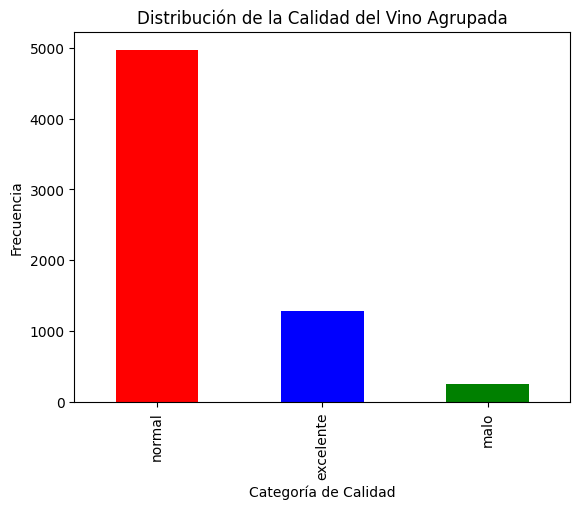

In [7]:
import matplotlib.pyplot as plt

# Plot the distribution of the 'quality_grouped' variable
df_wines['quality_grouped'].value_counts().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Distribución de la Calidad del Vino Agrupada')
plt.xlabel('Categoría de Calidad')
plt.ylabel('Frecuencia')
plt.show()

In [8]:
X = df_wines.drop(['quality', 'quality_grouped'], axis=1)
Y = df_wines['quality_grouped']

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=21)

In [10]:
modelos_base = [
    ('Logistic Regression', LogisticRegression( random_state=33,class_weight='balanced')),
    ('Gaussian Process', GaussianProcessClassifier(random_state=33)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5)),
    ('Support Vector Machine', SVC(kernel='rbf', probability=True, random_state=33,class_weight='balanced')),
    ('Decision Tree', DecisionTreeClassifier(random_state=33,class_weight='balanced'))
]

In [11]:
meta_model = MLPClassifier(hidden_layer_sizes=(128,64,32),random_state=33, max_iter=500)

El stacking es un tipo de ensamblado donde se entrena un conjunto de modelos base y se utiliza las predicciones de estos(probabilidad y/o etiqueta) como input para entrenar un meta-modelo (en nuestro caso una red neuronal). en scikit-learn la clase stackinClassifier nos permite realizar esto de forma simple.   

In [12]:
clf = StackingClassifier(
    estimators=modelos_base, final_estimator=meta_model)


In [13]:
pipe = make_pipeline(StandardScaler(), clf)

In [14]:
pipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('stackingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('Logistic Regression', ...), ('Gaussian Process', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",MLPClassifier...ndom_state=33)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the sp

In [15]:
print(classification_report(Y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

   excelente       0.74      0.43      0.54       256
        malo       0.18      0.04      0.07        49
      normal       0.83      0.96      0.89       995

    accuracy                           0.82      1300
   macro avg       0.59      0.48      0.50      1300
weighted avg       0.79      0.82      0.79      1300



In [16]:
X_train_scaled = pipe.named_steps['standardscaler'].transform(X_train)
X_test_scaled = pipe.named_steps['standardscaler'].transform(X_test)

for nombre, modelo in modelos_base:
    print(f"Entrenando modelo base: {nombre}")
    modelo.fit(X_train_scaled, Y_train)
    y_pred_base = modelo.predict(X_test_scaled)
    print(classification_report(Y_test, y_pred_base)) 

Entrenando modelo base: Logistic Regression
              precision    recall  f1-score   support

   excelente       0.39      0.75      0.52       256
        malo       0.08      0.49      0.14        49
      normal       0.87      0.46      0.60       995

    accuracy                           0.52      1300
   macro avg       0.45      0.56      0.42      1300
weighted avg       0.75      0.52      0.57      1300

Entrenando modelo base: Gaussian Process
              precision    recall  f1-score   support

   excelente       0.70      0.42      0.53       256
        malo       1.00      0.06      0.12        49
      normal       0.83      0.95      0.89       995

    accuracy                           0.81      1300
   macro avg       0.84      0.48      0.51      1300
weighted avg       0.81      0.81      0.79      1300

Entrenando modelo base: K-Nearest Neighbors
              precision    recall  f1-score   support

   excelente       0.60      0.52      0.56       256


De los resultados podemos concluir , que todos los modelos en general tienen problema a la hora de detectar un vino malo (pocos casos) , el que mejor lo logra es el árbol de decisión, si nos referimos a todos los vinos tenemos que el ensamblado logra superar a los modelos individuales. 